# 05 — Boolean QOS：expected unitary 与门级等价验证

本章只补前四章真正缺少的两块证据：

1. 作者 `qos.py` 使用的 **expected-unitary** 是否与大量显式随机流的平均一致；
2. 我们展开的 OpenQASM 2.0 echo 线路是否与直接相位公式逐点一致。

这里不复现论文 Figure 2。Figure 2 的准确率来自经典 Ridge/SVD，量子部分是
logical-space 公式；完整重跑不会验证任何量子线路，已移到未来发布版附录。

## 先认清符号和四个不同的“次数”

| 记号 | 白话含义 |
|---|---|
| $j$ | 数据流里第 $j$ 次到来的经典样本；只是先后顺序编号 |
| $x_j$ | 第 $j$ 个样本携带的地址 |
| $x$ | 泛指任意一个可能地址，不特指第几个样本 |
| $n$ | 地址量子位数 |
| $N=2^n$ | 一共有多少个可能地址 |
| $M$ / `M_data` | 一条 QOS 线路累计处理多少个经典样本/update |
| $C_x$ | 在这一条流里，地址 $x$ 一共出现几次 |
| $K_{\rm marked}$ | truth table 中满足 $f(x)=1$ 的地址数 |
| $R_{\rm streams}$ | 为做统计而独立生成多少条随机数据流/线路 |
| $S_{\rm shots}$ | 同一条线路重复测量多少次 |
| $F_{\rm echo}$ | 最后测得地址寄存器为 $0^n$ 的概率 |

**一个 sample update、一个 shot、一条独立 stream、一个云端 task
不是同一件事。** 例如 $n=2$ 时 $N=4$；若一条流是
$[0,3,1,3]$，则 $M=4$，计数向量为
$(C_0,C_1,C_2,C_3)=(1,1,0,2)$。这里的 $j=0,1,2,3$ 只表示四次
到达顺序，绝不是“第 $j$ 个量子位”。

对一条长度为 $M$ 的 IID 均匀地址流，令 $C_x$ 为地址 $x$ 出现的次数，
$N=2^n$，每个有效样本的相位为

$$
\theta=\frac{\pi N}{M}.
$$

QOS sketch 与精确逆 oracle 组成 echo 后，成功概率是

$$
F_{\rm echo}
=
\left|
\frac{1}{N}
\sum_x
\exp\left\{
i\left[\theta C_x-\pi\right]f(x)
\right\}
\right|^2.
$$

它是特定输入 $|+\rangle^{\otimes n}$ 上的 state fidelity，
不是 channel fidelity、process fidelity 或 diamond norm。


In [1]:
import hashlib
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit import qasm2
from qiskit.quantum_info import Statevector

SEED = 20260729
R_STREAMS = 1200
M_RATIOS = np.array([1, 2, 4, 8, 16, 32, 64])

asset_figure_dir = Path("../assets/figures")
asset_circuit_dir = Path("../assets/circuits")
results_dir = Path("../results")
for directory in (asset_figure_dir, asset_circuit_dir, results_dir):
    directory.mkdir(parents=True, exist_ok=True)


## 1. 三个不同对象

初学时最容易把下面三个量混为一谈：

| 对象 | 含义 | 是否是一条可执行量子线路 |
|---|---|---:|
| 单条 sampled sketch | 固定一条随机流后得到的 unitary | 是 |
| expected operator | 对所有随机流的 unitary 取平均 | 通常不是 |
| $\mathbb E[F_{\rm echo}]$ | 对每条物理线路的成功率再取平均 | 是实验均值 |

expected operator 一般会发生幅度收缩，所以不是 unitary；而且

$$
F\!\left(\mathbb E[U]\right)
\neq
\mathbb E\!\left[F(U)\right].
$$

因此本章同时给出两种解析量，避免把作者的高效 surrogate 当成单条硬件线路。


In [2]:
def truth_table(n_address, kind, seed=SEED):
    n_states = 2**n_address
    if kind == "parity":
        values = [x.bit_count() % 2 for x in range(n_states)]
    elif kind == "marked":
        values = [int(x == n_states - 1) for x in range(n_states)]
    elif kind == "majority":
        threshold = (n_address + 1) // 2
        values = [
            int(x.bit_count() >= threshold) for x in range(n_states)
        ]
    elif kind == "random":
        local_rng = np.random.default_rng(seed + 101 * n_address)
        values = local_rng.integers(0, 2, size=n_states)
        if np.all(values == values[0]):
            values[-1] = 1 - values[-1]
    else:
        raise ValueError(f"Unknown function kind: {kind}")
    return np.asarray(values, dtype=np.int8)


def draw_stream(rng, n_states, m_data, mode="iid"):
    if mode == "iid":
        return rng.integers(0, n_states, size=m_data, dtype=np.int64)
    if mode == "balanced":
        if m_data % n_states:
            raise ValueError("Balanced stream requires M_data % N == 0.")
        stream = np.tile(np.arange(n_states), m_data // n_states)
        rng.shuffle(stream)
        return stream
    raise ValueError(f"Unknown stream mode: {mode}")


def target_diagonal(f_values):
    f_values = np.asarray(f_values, dtype=np.int8)
    return np.exp(1j * np.pi * f_values)


def sampled_diagonal(f_values, stream):
    f_values = np.asarray(f_values, dtype=np.int8)
    stream = np.asarray(stream, dtype=np.int64)
    n_states = len(f_values)
    theta = np.pi * n_states / len(stream)
    counts = np.bincount(stream, minlength=n_states)
    return np.exp(1j * theta * counts * f_values)


def expected_diagonal(f_values, m_data):
    f_values = np.asarray(f_values, dtype=np.int8)
    n_states = len(f_values)
    theta = np.pi * n_states / m_data
    single_step = 1 + (
        np.exp(1j * theta * f_values) - 1
    ) / n_states
    return single_step**m_data


def echo_fidelity_from_diagonal(sketch_diagonal, f_values):
    residual = np.asarray(sketch_diagonal) * np.conj(
        target_diagonal(f_values)
    )
    return float(abs(np.mean(residual)) ** 2)


def sampled_echo_fidelity(f_values, stream):
    return echo_fidelity_from_diagonal(
        sampled_diagonal(f_values, stream), f_values
    )


def expected_operator_echo_fidelity(n_states, num_marked, m_data):
    theta = np.pi * n_states / m_data
    a = (
        1 - 1 / n_states + np.exp(1j * theta) / n_states
    ) ** m_data
    amplitude = (n_states - num_marked - num_marked * a) / n_states
    return float(abs(amplitude) ** 2)


def expected_physical_echo_fidelity(n_states, num_marked, m_data):
    theta = np.pi * n_states / m_data
    a = (
        1 - 1 / n_states + np.exp(1j * theta) / n_states
    ) ** m_data
    b = (
        1 + 2 * (np.cos(theta) - 1) / n_states
    ) ** m_data
    unmarked = n_states - num_marked
    numerator = (
        unmarked**2
        + num_marked
        + num_marked * (num_marked - 1) * b
        - 2 * num_marked * unmarked * np.real(a)
    )
    return float(numerator / n_states**2)


def normalized_operator_rmse(left, right):
    return float(np.sqrt(np.mean(np.abs(left - right) ** 2)))


## 2. 闭式结果先做回归测试

若 truth table 中有 $K_{\rm marked}$ 个 marked 地址，定义

$$
a=
\left(
1-\frac1N+\frac{e^{i\theta}}N
\right)^M,
\qquad
b=
\left[
1+\frac{2(\cos\theta-1)}N
\right]^M.
$$

expected-operator surrogate 的 echo fidelity 为

$$
F_{\rm mean\ op}
=
\left|
\frac{N-K_{\rm marked}-K_{\rm marked}a}{N}
\right|^2.
$$

真正对独立物理线路成功率取平均则是

$$
\mathbb E[F_{\rm echo}]
=
\frac{
(N-K_{\rm marked})^2+K_{\rm marked}
+K_{\rm marked}(K_{\rm marked}-1)b
-2K_{\rm marked}(N-K_{\rm marked})\operatorname{Re}(a)
}{N^2}.
$$

下面先用若干固定数值检查实现，再用 Monte Carlo 验证。


In [3]:
regression_cases = [
    (4, 1, 4, 0.601562),
    (4, 1, 16, 0.771671),
    (4, 2, 8, 0.439819),
    (8, 1, 16, 0.800797),
    (8, 4, 64, 0.659064),
]

for n_states, num_marked, m_data, expected in regression_cases:
    observed = expected_physical_echo_fidelity(
        n_states, num_marked, m_data
    )
    if not np.isclose(observed, expected, atol=5e-6):
        raise AssertionError(
            (n_states, num_marked, m_data, observed, expected)
        )

print("Closed-form regression checks passed:", len(regression_cases))


Closed-form regression checks passed: 5


In [4]:
rng = np.random.default_rng(SEED)
analytic_rows = []

for function_kind in ("parity", "marked"):
    f_values = truth_table(3, function_kind)
    n_states = len(f_values)
    num_marked = int(f_values.sum())

    for ratio in M_RATIOS:
        m_data = int(ratio * n_states)
        stream_diagonals = np.empty(
            (R_STREAMS, n_states), dtype=np.complex128
        )
        stream_fidelities = np.empty(R_STREAMS)

        for stream_index in range(R_STREAMS):
            stream = draw_stream(rng, n_states, m_data, mode="iid")
            diagonal = sampled_diagonal(f_values, stream)
            stream_diagonals[stream_index] = diagonal
            stream_fidelities[stream_index] = (
                echo_fidelity_from_diagonal(diagonal, f_values)
            )

        mean_diagonal = stream_diagonals.mean(axis=0)
        expected_mean_diagonal = expected_diagonal(
            f_values, m_data
        )
        expected_physical = expected_physical_echo_fidelity(
            n_states, num_marked, m_data
        )
        expected_surrogate = expected_operator_echo_fidelity(
            n_states, num_marked, m_data
        )

        per_address_variance = np.mean(
            np.abs(stream_diagonals - mean_diagonal) ** 2,
            axis=0,
        )
        mean_operator_se = np.sqrt(
            np.mean(per_address_variance) / R_STREAMS
        )
        mean_operator_gap = normalized_operator_rmse(
            mean_diagonal, expected_mean_diagonal
        )

        analytic_rows.append(
            {
                "function": function_kind,
                "N": n_states,
                "K_marked": num_marked,
                "M_data": m_data,
                "M_over_N": ratio,
                "R_streams": R_STREAMS,
                "mean_MC_F_echo": stream_fidelities.mean(),
                "MC_F_ci95": 1.96
                * stream_fidelities.std(ddof=1)
                / np.sqrt(R_STREAMS),
                "analytic_E_F_echo": expected_physical,
                "mean_operator_surrogate_F": expected_surrogate,
                "MC_mean_operator_gap": mean_operator_gap,
                "gap_over_estimated_SE": mean_operator_gap
                / max(mean_operator_se, 1e-15),
            }
        )

analytic_summary = pd.DataFrame(analytic_rows)
display(analytic_summary)

max_fidelity_z = np.max(
    np.abs(
        analytic_summary["mean_MC_F_echo"]
        - analytic_summary["analytic_E_F_echo"]
    )
    / np.maximum(analytic_summary["MC_F_ci95"] / 1.96, 1e-15)
)
max_operator_z = analytic_summary["gap_over_estimated_SE"].max()
jensen_ok = np.all(
    analytic_summary["mean_operator_surrogate_F"]
    <= analytic_summary["analytic_E_F_echo"] + 1e-12
)

print("Max Monte Carlo fidelity z-score:", max_fidelity_z)
print("Max mean-operator normalized gap:", max_operator_z)
print("Surrogate <= physical mean on grid:", jensen_ok)

assert max_fidelity_z < 4.5
assert max_operator_z < 5.0
assert jensen_ok


,function,N,K_marked,M_data,M_over_N,R_streams,mean_MC_F_echo,MC_F_ci95,analytic_E_F_echo,mean_operator_surrogate_F,MC_mean_operator_gap,gap_over_estimated_SE
0,parity,8,4,8,1,1200,0.264062,0.013571,0.263176,0.202449,0.008463,0.416701
1,parity,8,4,16,2,1200,0.355312,0.011089,0.359057,0.299493,0.011162,0.552099
2,parity,8,4,32,4,1200,0.485019,0.011212,0.498327,0.449417,0.022578,1.172317
3,parity,8,4,64,8,1200,0.666442,0.010258,0.659064,0.627095,0.010525,0.639987
4,parity,8,4,128,16,1200,0.794247,0.006975,0.795552,0.777631,0.011208,0.848464
5,parity,8,4,256,32,1200,0.890955,0.004294,0.887146,0.877783,0.006737,0.688033
6,parity,8,4,512,64,1200,0.939290,0.002407,0.940586,0.935826,0.003988,0.544277
7,marked,8,1,8,1,1200,0.759010,0.012318,0.759350,0.743882,0.000549,0.054104
8,marked,8,1,16,2,1200,0.805130,0.008790,0.800797,0.785473,0.007040,0.697793
9,marked,8,1,32,4,1200,0.865447,0.007366,0.855352,0.841605,0.017510,1.868063


Max Monte Carlo fidelity z-score: 2.686016194595852
Max mean-operator normalized gap: 2.837740974024675
Surrogate <= physical mean on grid: True


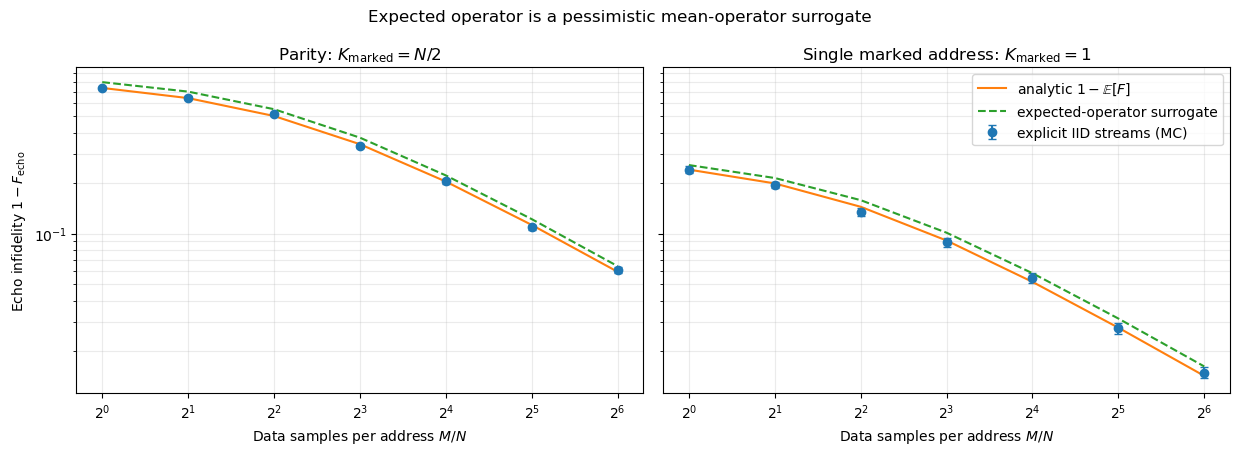

Saved: ../assets/figures/expected-unitary-validation.png


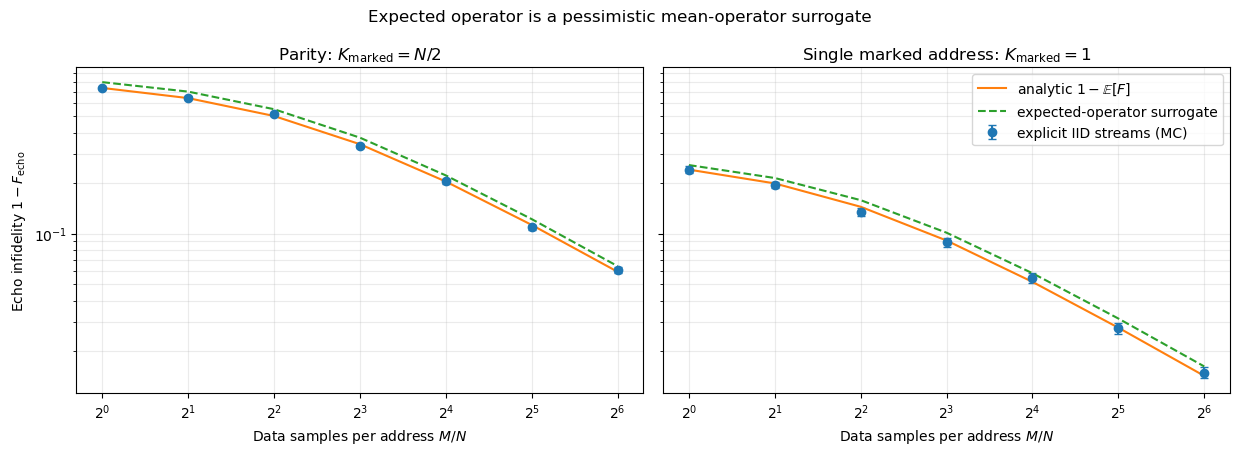

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)

for ax, function_kind in zip(axes, ("parity", "marked")):
    subset = analytic_summary[
        analytic_summary["function"] == function_kind
    ].sort_values("M_over_N")

    ax.errorbar(
        subset["M_over_N"],
        1 - subset["mean_MC_F_echo"],
        yerr=subset["MC_F_ci95"],
        marker="o",
        capsize=3,
        linestyle="none",
        label="explicit IID streams (MC)",
    )
    ax.plot(
        subset["M_over_N"],
        1 - subset["analytic_E_F_echo"],
        marker=None,
        label=r"analytic $1-\mathbb{E}[F]$",
    )
    ax.plot(
        subset["M_over_N"],
        1 - subset["mean_operator_surrogate_F"],
        linestyle="--",
        label="expected-operator surrogate",
    )
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set(
        xlabel=r"Data samples per address $M/N$",
        title=(
            r"Parity: $K_{\rm marked}=N/2$"
            if function_kind == "parity"
            else r"Single marked address: $K_{\rm marked}=1$"
        ),
    )
    ax.grid(True, which="both", alpha=0.25)

axes[0].set_ylabel(r"Echo infidelity $1-F_{\rm echo}$")
axes[1].legend(loc="best")
fig.suptitle(
    "Expected operator is a pessimistic mean-operator surrogate"
)
fig.tight_layout()
figure_path = asset_figure_dir / "expected-unitary-validation.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
display(fig)
print("Saved:", figure_path)


图中的虚线不是“另一台量子计算机的实验结果”，而是作者为了高效模拟所用的
mean-operator surrogate。Monte Carlo 点与真正的解析
$\mathbb E[F_{\rm echo}]$ 对齐，说明两层平均已被正确区分。

纵轴是错误量 $1-F_{\rm echo}$，**越低越好**；横轴每向右一格，
$M/N$ 翻倍；Monte Carlo 误差棒是跨 $R_{\rm streams}=1200$ 条独立流的
近似 95% 区间半宽。parity 和任意其他含相同
$K_{\rm marked}$ 的 truth table，在 IID 均匀采样与 $|+\rangle$ echo
的理论均值上相同；函数的地址布局只会在门映射、路由和硬件误差中重新
变得重要。


## 3. 把 projector phase 展开为 OpenQASM 2.0

对 $n=1,2$，分别使用 CX 或 CCX 计算 equality flag。

对 $n=3$，使用两个 clean work qubits：

```text
CCX(q0,q1,work0)
  → CCX(work0,q2,flag)
  → U1(theta) on flag
  → reverse both CCX
```

因而每个有效的 $n=3$ projector update 含 4 个 CCX。它适合离线
扩展性/门数压力测试，但不应被描述为“只用 5 qubits 所以真机很容易”。

默认在每个有效样本更新后插入 barrier，保持样本边界。barrier 仍不能把
预先展开的静态 QASM 变成真正在线 streaming controller。


In [6]:
def work_qubit_count(n_address):
    if n_address in (1, 2):
        return 1
    if n_address == 3:
        return 2
    raise NotImplementedError(
        "Auditable gate prototype currently supports n=1,2,3."
    )


def append_projector_phase_qasm(
    lines,
    n_address,
    address,
    theta,
    preserve_update_boundary=True,
):
    if n_address not in (1, 2, 3):
        raise NotImplementedError
    if not 0 <= address < 2**n_address:
        raise ValueError("Address is outside the address register.")

    zero_bits = [
        bit
        for bit in range(n_address)
        if ((address >> bit) & 1) == 0
    ]
    for bit in zero_bits:
        lines.append(f"x q[{bit}];")

    if n_address == 1:
        flag = 1
        lines.append("cx q[0],q[1];")
    elif n_address == 2:
        flag = 2
        lines.append("ccx q[0],q[1],q[2];")
    else:
        work0, flag = 3, 4
        lines.append(f"ccx q[0],q[1],q[{work0}];")
        lines.append(f"ccx q[{work0}],q[2],q[{flag}];")

    lines.append(f"u1({float(theta):.16g}) q[{flag}];")

    if n_address == 1:
        lines.append("cx q[0],q[1];")
    elif n_address == 2:
        lines.append("ccx q[0],q[1],q[2];")
    else:
        lines.append(f"ccx q[{work0}],q[2],q[{flag}];")
        lines.append(f"ccx q[0],q[1],q[{work0}];")

    for bit in reversed(zero_bits):
        lines.append(f"x q[{bit}];")
    if preserve_update_boundary:
        lines.append("barrier q;")


def build_boolean_echo_qasm(
    f_values,
    stream,
    preserve_update_boundaries=True,
):
    f_values = np.asarray(f_values, dtype=np.int8)
    stream = np.asarray(stream, dtype=np.int64)
    n_states = len(f_values)
    n_address = int(np.log2(n_states))
    if 2**n_address != n_states:
        raise ValueError("Truth-table length must be a power of two.")
    if n_address not in (1, 2, 3):
        raise NotImplementedError
    if len(stream) == 0:
        raise ValueError("Stream must not be empty.")
    if np.any((stream < 0) | (stream >= n_states)):
        raise ValueError("Stream contains an invalid address.")

    n_total = n_address + work_qubit_count(n_address)
    theta = np.pi * n_states / len(stream)
    lines = [
        "OPENQASM 2.0;",
        'include "qelib1.inc";',
        f"qreg q[{n_total}];",
        f"creg c[{n_address}];",
    ]
    for bit in range(n_address):
        lines.append(f"h q[{bit}];")
    lines.append("barrier q;")

    for address in stream:
        if f_values[address] == 1:
            append_projector_phase_qasm(
                lines,
                n_address,
                int(address),
                theta,
                preserve_update_boundaries,
            )

    lines.append("barrier q;")
    for address, value in enumerate(f_values):
        if value == 1:
            append_projector_phase_qasm(
                lines,
                n_address,
                address,
                -np.pi,
                preserve_update_boundaries,
            )

    lines.append("barrier q;")
    for bit in range(n_address):
        lines.append(f"h q[{bit}];")
        lines.append(f"measure q[{bit}] -> c[{bit}];")
    return "\n".join(lines) + "\n"


def qasm_echo_metrics(qasm_text, n_address):
    circuit = qasm2.loads(qasm_text)
    bare_circuit = circuit.remove_final_measurements(inplace=False)
    state = Statevector.from_instruction(bare_circuit)
    probabilities = np.abs(state.data) ** 2
    indices = np.arange(len(probabilities))
    address_zero = (indices & ((1 << n_address) - 1)) == 0
    work_nonzero = np.array(
        [
            any(
                ((index >> qubit) & 1) == 1
                for qubit in range(
                    n_address, bare_circuit.num_qubits
                )
            )
            for index in indices
        ]
    )
    return {
        "F_echo_qasm": float(probabilities[address_zero].sum()),
        "work_leakage": float(probabilities[work_nonzero].sum()),
        "depth_with_barriers": circuit.depth(),
        "ops": dict(circuit.count_ops()),
        "circuit": circuit,
        "statevector": np.asarray(state.data),
    }


def direct_echo_statevector(f_values, stream, n_total_qubits):
    f_values = np.asarray(f_values, dtype=np.int8)
    stream = np.asarray(stream, dtype=np.int64)
    n_states = len(f_values)
    theta = np.pi * n_states / len(stream)
    counts = np.bincount(stream, minlength=n_states)
    residual_phase = np.exp(
        1j * (theta * counts - np.pi) * f_values
    )

    # Qiskit uses q0 as the least-significant computational-basis bit.
    # After the final H^n, this is the Walsh-Hadamard transform.
    address_state = np.empty(n_states, dtype=np.complex128)
    for output_address in range(n_states):
        signs = np.asarray(
            [
                -1
                if (output_address & input_address).bit_count() % 2
                else 1
                for input_address in range(n_states)
            ]
        )
        address_state[output_address] = (
            np.dot(signs, residual_phase) / n_states
        )

    full_state = np.zeros(
        2**n_total_qubits, dtype=np.complex128
    )
    full_state[:n_states] = address_state
    return full_state


下一张线路图只画**一次** $n=3$、地址 $x=5$ 的 projector-phase update：

- `q_0,q_1,q_2` 是三个 address qubits；
- `q_3` 是中间 work qubit；
- `q_4` 是承载相位的 equality flag；
- 十进制 $5$ 的二进制是 $101$。Qiskit 按 little-endian 显示，
  所以只需对表示中间位的 `q_1` 加 X mask；
- 图左端所有线标成 $|0\rangle$ 是线路绘图约定，并不是说 projector
  只能接收地址 $000$。

线路中的 barrier 只是编译边界提示，不是物理量子门，也不应计入二比特门数。


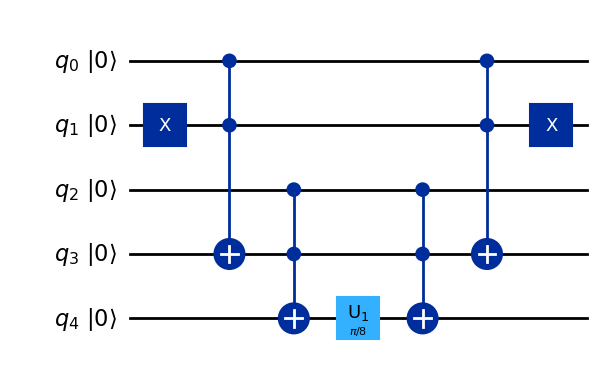

Saved: ../assets/circuits/projector-phase-update-n3.png


In [7]:
single_n3_lines = [
    "OPENQASM 2.0;",
    'include "qelib1.inc";',
    "qreg q[5];",
]
append_projector_phase_qasm(
    single_n3_lines,
    n_address=3,
    address=5,
    theta=np.pi / 8,
    preserve_update_boundary=False,
)
single_n3_qasm = "\n".join(single_n3_lines) + "\n"
single_n3_circuit = qasm2.loads(single_n3_qasm)
single_n3_figure = single_n3_circuit.draw(
    output="mpl",
    fold=-1,
    idle_wires=False,
    initial_state=True,
)
single_n3_path = asset_circuit_dir / "projector-phase-update-n3.png"
single_n3_figure.savefig(
    single_n3_path, dpi=180, bbox_inches="tight"
)
display(single_n3_figure)
print("Saved:", single_n3_path)


In [8]:
equivalence_rng = np.random.default_rng(SEED + 10)
equivalence_rows = []
representative_qasm = None

for n_address in (1, 2, 3):
    for function_kind in ("parity", "marked", "majority", "random"):
        f_values = truth_table(n_address, function_kind)
        for stream_mode in ("balanced", "iid"):
            for ratio in (2, 4):
                n_states = len(f_values)
                m_data = ratio * n_states
                stream = draw_stream(
                    equivalence_rng,
                    n_states,
                    m_data,
                    mode=stream_mode,
                )
                qasm_text = build_boolean_echo_qasm(
                    f_values,
                    stream,
                    preserve_update_boundaries=True,
                )
                qasm_metrics = qasm_echo_metrics(
                    qasm_text, n_address
                )
                direct_fidelity = sampled_echo_fidelity(
                    f_values, stream
                )
                ops = qasm_metrics["ops"]
                qasm_state = qasm_metrics["statevector"]
                direct_state = direct_echo_statevector(
                    f_values,
                    stream,
                    qasm_metrics["circuit"].num_qubits,
                )
                global_phase_overlap = np.vdot(
                    direct_state, qasm_state
                )
                if abs(global_phase_overlap) < 1e-14:
                    raise AssertionError(
                        "Direct and QASM states are unexpectedly orthogonal."
                    )
                phase_factor = (
                    global_phase_overlap
                    / abs(global_phase_overlap)
                )
                aligned_qasm_state = qasm_state / phase_factor
                state_delta = aligned_qasm_state - direct_state

                equivalence_rows.append(
                    {
                        "n_address": n_address,
                        "N": n_states,
                        "function": function_kind,
                        "stream_mode": stream_mode,
                        "M_data": m_data,
                        "F_echo_direct": direct_fidelity,
                        "F_echo_qasm": qasm_metrics["F_echo_qasm"],
                        "absolute_error": abs(
                            direct_fidelity
                            - qasm_metrics["F_echo_qasm"]
                        ),
                        "full_state_l2_error": float(
                            np.linalg.norm(state_delta)
                        ),
                        "full_state_max_abs_error": float(
                            np.max(np.abs(state_delta))
                        ),
                        "global_phase_overlap_abs": float(
                            abs(global_phase_overlap)
                        ),
                        "work_leakage": qasm_metrics["work_leakage"],
                        "cx": int(ops.get("cx", 0)),
                        "ccx": int(ops.get("ccx", 0)),
                        "u1": int(ops.get("u1", 0)),
                        "depth_with_barriers": qasm_metrics[
                            "depth_with_barriers"
                        ],
                        "qasm_sha256": hashlib.sha256(
                            qasm_text.encode("utf-8")
                        ).hexdigest(),
                    }
                )

                if (
                    representative_qasm is None
                    and n_address == 1
                    and function_kind == "parity"
                    and stream_mode == "balanced"
                ):
                    representative_qasm = qasm_text

equivalence = pd.DataFrame(equivalence_rows)
display(equivalence.head(12))
display(
    equivalence.groupby(["n_address", "function"])[
        [
            "absolute_error",
            "full_state_l2_error",
            "full_state_max_abs_error",
            "work_leakage",
        ]
    ]
    .max()
    .rename(columns=lambda name: f"max_{name}")
)

max_equivalence_error = equivalence["absolute_error"].max()
max_full_state_l2_error = equivalence[
    "full_state_l2_error"
].max()
max_full_state_abs_error = equivalence[
    "full_state_max_abs_error"
].max()
max_work_leakage = equivalence["work_leakage"].max()
max_balanced_error = np.max(
    np.abs(
        equivalence.loc[
            equivalence["stream_mode"] == "balanced",
            "F_echo_qasm",
        ]
        - 1
    )
)

print("Maximum direct-vs-QASM error:", max_equivalence_error)
print("Maximum full-state L2 error:", max_full_state_l2_error)
print(
    "Maximum full-state amplitude error:",
    max_full_state_abs_error,
)
print("Maximum work-ancilla leakage:", max_work_leakage)
print("Maximum balanced-stream error from one:", max_balanced_error)

assert max_equivalence_error < 1e-10
assert max_full_state_l2_error < 1e-10
assert max_full_state_abs_error < 1e-10
assert max_work_leakage < 1e-10
assert max_balanced_error < 1e-10


,n_address,N,function,stream_mode,M_data,F_echo_direct,F_echo_qasm,absolute_error,full_state_l2_error,full_state_max_abs_error,global_phase_overlap_abs,work_leakage,cx,ccx,u1,depth_with_barriers,qasm_sha256
0,1,2,parity,balanced,4,1.000000e+00,1.000000e+00,4.440892e-16,4.970106e-16,4.446523e-16,1.0,0.0,6,0,3,12,2005cefeed14d4569dc6ef1e5e7a78dcaa20616c224814...
1,1,2,parity,balanced,8,1.000000e+00,1.000000e+00,4.440892e-16,2.497124e-16,2.220446e-16,1.0,0.0,10,0,5,18,2457fd407db8f487ea3c039442de40c7f108313264ccf4...
2,1,2,parity,iid,4,1.000000e+00,1.000000e+00,4.440892e-16,4.970106e-16,4.446523e-16,1.0,0.0,6,0,3,12,2005cefeed14d4569dc6ef1e5e7a78dcaa20616c224814...
3,1,2,parity,iid,8,8.535534e-01,8.535534e-01,2.220446e-16,2.167780e-16,1.861901e-16,1.0,0.0,12,0,6,21,89dd64b07ff2bb03a5cbce6d5a87cc90fef40b124abaea...
4,1,2,marked,balanced,4,1.000000e+00,1.000000e+00,4.440892e-16,4.970106e-16,4.446523e-16,1.0,0.0,6,0,3,12,2005cefeed14d4569dc6ef1e5e7a78dcaa20616c224814...
5,1,2,marked,balanced,8,1.000000e+00,1.000000e+00,4.440892e-16,2.497124e-16,2.220446e-16,1.0,0.0,10,0,5,18,2457fd407db8f487ea3c039442de40c7f108313264ccf4...
6,1,2,marked,iid,4,3.749399e-33,6.843403e-31,6.805909e-31,9.157866e-16,8.884601e-16,1.0,0.0,10,0,5,18,65c4ae4efd6c967407685481c9015e49ffe8fc0177039a...
7,1,2,marked,iid,8,8.535534e-01,8.535534e-01,2.220446e-16,2.167780e-16,1.861901e-16,1.0,0.0,12,0,6,21,89dd64b07ff2bb03a5cbce6d5a87cc90fef40b124abaea...
8,1,2,majority,balanced,4,1.000000e+00,1.000000e+00,4.440892e-16,4.970106e-16,4.446523e-16,1.0,0.0,6,0,3,12,2005cefeed14d4569dc6ef1e5e7a78dcaa20616c224814...
9,1,2,majority,balanced,8,1.000000e+00,1.000000e+00,4.440892e-16,2.497124e-16,2.220446e-16,1.0,0.0,10,0,5,18,2457fd407db8f487ea3c039442de40c7f108313264ccf4...


max_absolute_error  max_full_state_l2_error  \
n_address function                                                
1         majority        4.440892e-16             4.970106e-16   
          marked          4.440892e-16             9.157866e-16   
          parity          4.440892e-16             4.970106e-16   
          random          4.440892e-16             4.970106e-16   
2         majority        6.661338e-16             5.102800e-16   
          marked          6.661338e-16             5.098066e-16   
          parity          8.881784e-16             6.503339e-16   
          random          6.661338e-16             8.382000e-16   
3         majority        1.110223e-15             6.642156e-16   
          marked          1.332268e-15             5.646572e-16   
          parity          1.332268e-15             8.930440e-16   
          random          1.332268e-15             6.820710e-16   

                    max_full_state_max_abs_error  max_work_leakage  
n_address function                                                  
1         majority                  4.446523e-16               0.0  
          marked                    8.884601e-16               0.0  
          parity                    4.446523e-16               0.0  
          random                    4.446523e-16               0.0  
2         majority                  3.855928e-16               0.0  
          marked                    3.376612e-16               0.0  
          parity                    5.236912e-16               0.0  
          random                    6.866350e-16               0.0  
3         majority                  5.551115e-16               0.0  
          marked                    5.594315e-16               0.0  
          parity                    6.661338e-16               0.0  
          random                    6.661338e-16               0.0

Maximum direct-vs-QASM error: 1.3322676295501878e-15
Maximum full-state L2 error: 9.157866453733048e-16
Maximum full-state amplitude error: 8.884601134928783e-16
Maximum work-ancilla leakage: 0.0
Maximum balanced-stream error from one: 1.3322676295501878e-15


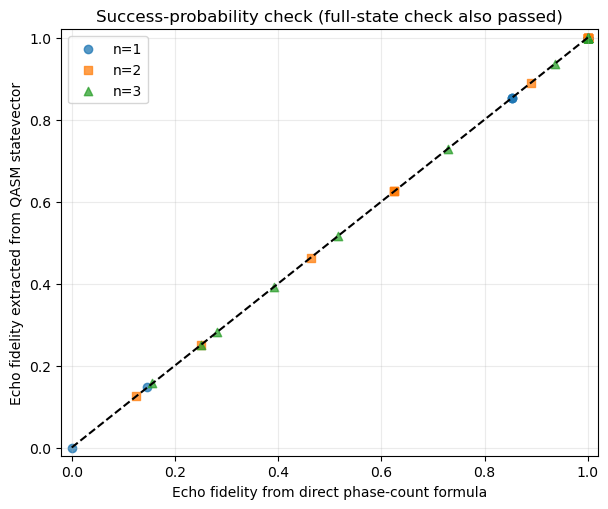

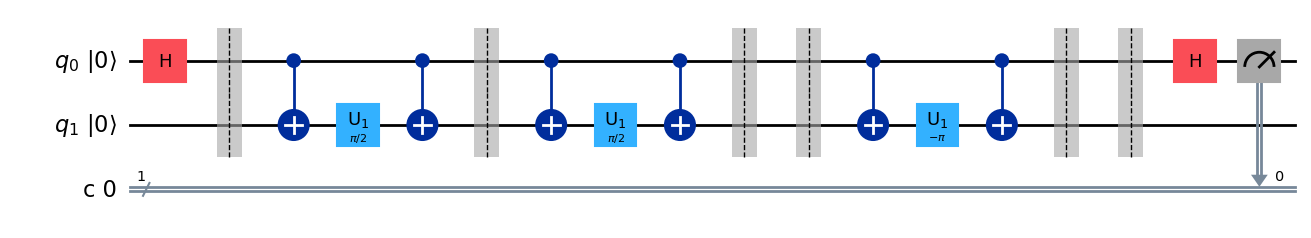

Saved: ../assets/figures/qasm-equivalence-validation.png
Saved: ../assets/circuits/qos-equivalence-n1.png


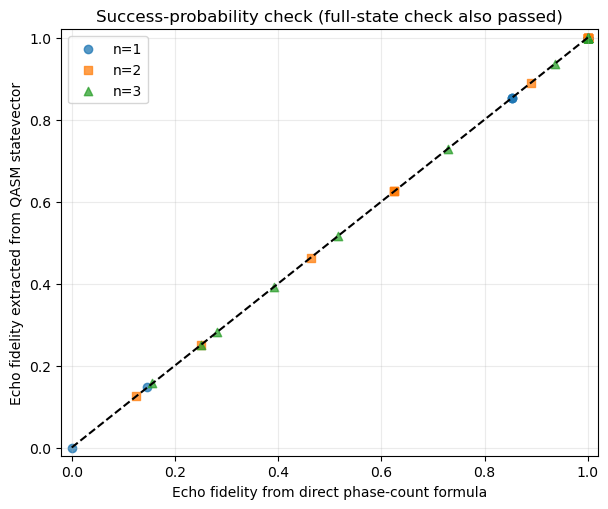

In [9]:
fig, ax = plt.subplots(figsize=(6.2, 5.2))
for n_address, marker in ((1, "o"), (2, "s"), (3, "^")):
    subset = equivalence[equivalence["n_address"] == n_address]
    ax.scatter(
        subset["F_echo_direct"],
        subset["F_echo_qasm"],
        marker=marker,
        alpha=0.75,
        label=f"n={n_address}",
    )
ax.plot([0, 1], [0, 1], color="black", linestyle="--")
ax.set(
    xlabel="Echo fidelity from direct phase-count formula",
    ylabel="Echo fidelity extracted from QASM statevector",
    title="Success-probability check (full-state check also passed)",
    xlim=(-0.02, 1.02),
    ylim=(-0.02, 1.02),
)
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
equivalence_figure_path = (
    asset_figure_dir / "qasm-equivalence-validation.png"
)
fig.savefig(
    equivalence_figure_path, dpi=180, bbox_inches="tight"
)
display(fig)

representative_circuit = qasm2.loads(representative_qasm)
representative_figure = representative_circuit.draw(
    output="mpl",
    fold=30,
    idle_wires=False,
    initial_state=True,
)
circuit_path = asset_circuit_dir / "qos-equivalence-n1.png"
representative_figure.savefig(
    circuit_path, dpi=180, bbox_inches="tight"
)
display(representative_figure)

print("Saved:", equivalence_figure_path)
print("Saved:", circuit_path)


散点贴在对角线上，表示两种方法算出的 $F_{\rm echo}$ 相同；这里约
$10^{-15}$ 的残差只是浮点舍入误差，**不是硬件误差**。更强的检查并未只
看一个概率：上一个单元还对 parity、marked、majority 和非对称 random
truth table 的**完整输出 statevector**做了全局相位对齐，再比较每个复振幅。
这一步能捕捉地址位序、端序和反计算错误。


In [10]:
analytic_path = results_dir / "expected_unitary_validation.csv"
equivalence_path = results_dir / "qasm_equivalence_validation.csv"
analytic_summary.to_csv(analytic_path, index=False)
equivalence.to_csv(equivalence_path, index=False)

validation_summary = {
    "seed": SEED,
    "R_streams": R_STREAMS,
    "max_fidelity_z_score": float(max_fidelity_z),
    "max_mean_operator_normalized_gap": float(max_operator_z),
    "max_direct_vs_qasm_error": float(max_equivalence_error),
    "max_full_state_l2_error": float(
        max_full_state_l2_error
    ),
    "max_full_state_amplitude_error": float(
        max_full_state_abs_error
    ),
    "max_work_ancilla_leakage": float(max_work_leakage),
    "max_balanced_stream_error_from_one": float(
        max_balanced_error
    ),
}
summary_path = results_dir / "boolean_equivalence_summary.json"
summary_path.write_text(
    json.dumps(validation_summary, indent=2),
    encoding="utf-8",
)

print("Saved:", analytic_path)
print("Saved:", equivalence_path)
print("Saved:", summary_path)


Saved: ../results/expected_unitary_validation.csv
Saved: ../results/qasm_equivalence_validation.csv
Saved: ../results/boolean_equivalence_summary.json


## 本章结论与边界

本章通过了三个独立检查：

1. 显式随机流的均值与 expected operator 一致；
2. 显式随机流的 fidelity 均值与闭式 $\mathbb E[F_{\rm echo}]$ 一致；
3. $n=1,2,3$ 的实际 QASM 完整 statevector 与直接相位计数公式一致
   （先对齐无物理意义的全局相位）。

这证明的是 **静态展开线路的数学与门级正确性**。exact inverse 由完整
truth table 生成，完整 QASM 也预存了样本门序列，所以它仍然不是系统级
streaming-memory advantage 的证明。
